First 5 Records
                                   Review  Rating
0  Excellent product, highly recommended!       5
1    Very good quality and fast delivery.       5
2                      Worth every penny.       5
3                        Amazing product.       5
4                   Good value for money.       4

Columns in Dataset
Index(['Review', 'Rating'], dtype='object')

Sentiment Count
Sentiment
Positive    19
Negative    11
Name: count, dtype: int64

Accuracy : 0.5

Classification Report
              precision    recall  f1-score   support

    Negative       0.25      1.00      0.40         1
    Positive       1.00      0.40      0.57         5

    accuracy                           0.50         6
   macro avg       0.62      0.70      0.49         6
weighted avg       0.88      0.50      0.54         6



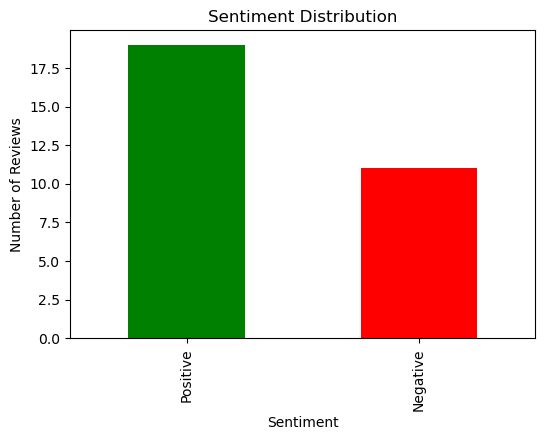

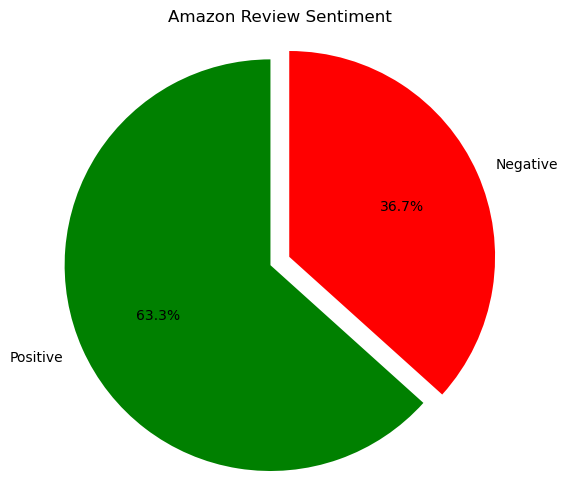


Emotion Count
Emotion
Neutral    18
Happy       8
Sad         3
Angry       1
Name: count, dtype: int64


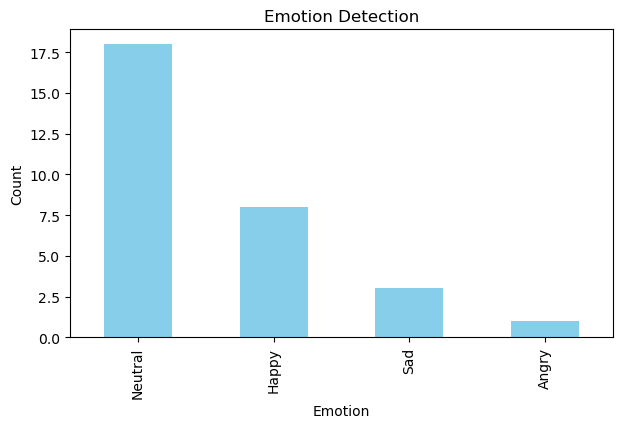


SOCIAL MEDIA SENTIMENT ANALYSIS
                       Post Sentiment
0         i love this phone  Positive
1  excellent camera quality  Positive
2    worst customer service  Negative
3      battery is very poor  Positive
4        amazing experience  Positive
5         very disappointed  Negative

NEWS SENTIMENT ANALYSIS
                                      News Sentiment
0      company launches amazing smartphone  Positive
1  customers complain about battery issues  Positive
2                  sales reach record high  Positive
3       product receives excellent reviews  Positive
4                  service quality is poor  Positive

PUBLIC OPINION AND TRENDS
Positive Reviews : 63.33 %
Negative Reviews : 36.67 %

Overall Public Opinion : Good
Trend : Majority of customers are satisfied.

MARKETING INSIGHTS
- Improve marketing strategy.
- Focus on customer trust.
- Run promotional offers.

PRODUCT DEVELOPMENT
- Analyze negative reviews.
- Improve product quality.
- Fix recurring issues

In [1]:
# ===============================================
# TASK 4 - SENTIMENT ANALYSIS
# Amazon Reviews + Social Media + News Analysis
# ===============================================

import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# ===============================================
# Load Dataset
# ===============================================

df = pd.read_csv("amazon_reviews.csv")

print("First 5 Records")
print(df.head())

print("\nColumns in Dataset")
print(df.columns)

# ===============================================
# Data Cleaning
# ===============================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df["Review"] = df["Review"].astype(str).apply(clean_text)

# ===============================================
# Create Sentiment Labels
# ===============================================

df["Sentiment"] = df["Rating"].apply(
    lambda x: "Positive" if x >= 3 else "Negative"
)

print("\nSentiment Count")
print(df["Sentiment"].value_counts())

# ===============================================
# Machine Learning Model
# ===============================================

X = df["Review"]
y = df["Sentiment"]

cv = CountVectorizer()

X_vector = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vector,
    y,
    test_size=0.2,
    random_state=42
)

model = MultinomialNB()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("\nAccuracy :", accuracy_score(y_test, prediction))

print("\nClassification Report")

print(classification_report(y_test, prediction))

# ===============================================
# Bar Chart
# ===============================================

plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green","red"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# ===============================================
# Pie Chart
# ===============================================

plt.figure(figsize=(6,6))

counts = df["Sentiment"].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["green","red"],
    explode=(0.05,0.05)
)

plt.title("Amazon Review Sentiment")
plt.axis("equal")
plt.show()

# ===============================================
# Emotion Detection
# ===============================================

emotion_words = {

"Happy":[
"good","great","excellent","amazing","love",
"best","awesome","fantastic","perfect"
],

"Sad":[
"bad","poor","disappointed","boring","slow"
],

"Angry":[
"worst","hate","terrible","awful","useless"
],

"Fear":[
"problem","issue","risk","danger","fault"
],

"Surprise":[
"unexpected","wow","surprised","unbelievable"
]

}

def detect_emotion(text):

    score = {}

    words = text.split()

    for emotion, keywords in emotion_words.items():

        score[emotion] = sum(word in keywords for word in words)

    if max(score.values()) == 0:
        return "Neutral"

    return max(score, key=score.get)

df["Emotion"] = df["Review"].apply(detect_emotion)

print("\nEmotion Count")

print(df["Emotion"].value_counts())

plt.figure(figsize=(7,4))

df["Emotion"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Emotion Detection")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

# ===============================================
# Social Media Analysis
# ===============================================

print("\n======================================")
print("SOCIAL MEDIA SENTIMENT ANALYSIS")
print("======================================")

social_posts = [

"I love this phone",

"Excellent camera quality",

"Worst customer service",

"Battery is very poor",

"Amazing experience",

"Very disappointed"

]

social_df = pd.DataFrame({"Post":social_posts})

social_df["Post"] = social_df["Post"].apply(clean_text)

social_vector = cv.transform(social_df["Post"])

social_df["Sentiment"] = model.predict(social_vector)

print(social_df)

# ===============================================
# News Sentiment Analysis
# ===============================================

print("\n======================================")
print("NEWS SENTIMENT ANALYSIS")
print("======================================")

news = [

"Company launches amazing smartphone",

"Customers complain about battery issues",

"Sales reach record high",

"Product receives excellent reviews",

"Service quality is poor"

]

news_df = pd.DataFrame({"News":news})

news_df["News"] = news_df["News"].apply(clean_text)

news_vector = cv.transform(news_df["News"])

news_df["Sentiment"] = model.predict(news_vector)

print(news_df)

# ===============================================
# Public Opinion and Trends
# ===============================================

percentage = df["Sentiment"].value_counts(normalize=True)*100

positive = percentage.get("Positive",0)

negative = percentage.get("Negative",0)

print("\n======================================")
print("PUBLIC OPINION AND TRENDS")
print("======================================")

print("Positive Reviews :",round(positive,2),"%")

print("Negative Reviews :",round(negative,2),"%")

if positive>=70:

    print("\nOverall Public Opinion : Excellent")

    print("Trend : Customers are highly satisfied.")

elif positive>=50:

    print("\nOverall Public Opinion : Good")

    print("Trend : Majority of customers are satisfied.")

else:

    print("\nOverall Public Opinion : Needs Improvement")

    print("Trend : Many customers are dissatisfied.")

# ===============================================
# Marketing Insights
# ===============================================

print("\n======================================")
print("MARKETING INSIGHTS")
print("======================================")

if positive>=70:

    print("- Highlight positive customer reviews in advertisements.")

    print("- Launch loyalty and referral programs.")

    print("- Promote best-selling products.")

else:

    print("- Improve marketing strategy.")

    print("- Focus on customer trust.")

    print("- Run promotional offers.")

# ===============================================
# Product Development
# ===============================================

print("\n======================================")
print("PRODUCT DEVELOPMENT")
print("======================================")

if negative>=20:

    print("- Analyze negative reviews.")

    print("- Improve product quality.")

    print("- Fix recurring issues.")

    print("- Enhance packaging and features.")

else:

    print("- Maintain product quality.")

    print("- Introduce innovative features.")

# ===============================================
# Social Insights
# ===============================================

print("\n======================================")
print("SOCIAL INSIGHTS")
print("======================================")

print("- Monitor customer opinions regularly.")

print("- Track sentiment trends over time.")

print("- Encourage customers to leave feedback.")

print("- Use social media listening tools.")

print("- Build stronger customer engagement.")

print("\nAnalysis Completed Successfully.")